In [129]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

import re
import random

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.set_num_threads(1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [130]:
#extracting datasets
df_cnbc = pd.read_csv('Dataset/cnbc_headlines.csv')
df_guardian = pd.read_csv('Dataset/guardian_headlines.csv')
df_reuters = pd.read_csv('Dataset/reuters_headlines.csv')

#considering only headlines
headline_cnbc = list(df_cnbc['Headlines'])
headline_guardian = list(df_guardian['Headlines'])
headline_reuters = list(df_reuters['Headlines'])

#list of headlines
headline_list = headline_cnbc + headline_guardian + headline_reuters

print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#cleaning dataset

#filtering empty rows
headline_list = [h for h in headline_list if str(h) != 'nan']
print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#removing spaces in headline
def clean_headline(h):
    h = h.strip() #remove the trailing spaces from either end
    h = re.sub(r'\s+', ' ', h) #replace bigger spaces with a single space
    h = h.encode('ascii', 'ignore').decode()  # remove non-ASCII
    return h

headline_list = [clean_headline(h) for h in headline_list]

No.of headlines in list:  53650
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", nan, "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally']
No.of headlines in list:  53370
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally', "Wall Street delivered the 'kind of pullback I've been waiting for,' Jim Cramer says"]


In [131]:
print(len(headline_list))

53370


In [132]:
#vocabulary set
unique_words = set()

for headline in headline_list:
    for letter in list(headline):
        unique_words.add(letter)
    
unique_words = ['<S>', '<E>'] + sorted(unique_words)
print("Vocabulary size: ",len(unique_words))

#number to word matrix
num2letter_dict = {i:letter for i, letter in enumerate(unique_words)}

#word to number matrix
letter2num_dict = {letter:i for i, letter in enumerate(unique_words)}


Vocabulary size:  84


In [133]:
print(letter2num_dict)

{'<S>': 0, '<E>': 1, ' ': 2, '!': 3, '"': 4, '#': 5, '$': 6, '%': 7, '&': 8, "'": 9, '(': 10, ')': 11, '*': 12, '+': 13, ',': 14, '-': 15, '.': 16, '/': 17, '0': 18, '1': 19, '2': 20, '3': 21, '4': 22, '5': 23, '6': 24, '7': 25, '8': 26, '9': 27, ':': 28, ';': 29, '?': 30, 'A': 31, 'B': 32, 'C': 33, 'D': 34, 'E': 35, 'F': 36, 'G': 37, 'H': 38, 'I': 39, 'J': 40, 'K': 41, 'L': 42, 'M': 43, 'N': 44, 'O': 45, 'P': 46, 'Q': 47, 'R': 48, 'S': 49, 'T': 50, 'U': 51, 'V': 52, 'W': 53, 'X': 54, 'Y': 55, 'Z': 56, '_': 57, 'a': 58, 'b': 59, 'c': 60, 'd': 61, 'e': 62, 'f': 63, 'g': 64, 'h': 65, 'i': 66, 'j': 67, 'k': 68, 'l': 69, 'm': 70, 'n': 71, 'o': 72, 'p': 73, 'q': 74, 'r': 75, 's': 76, 't': 77, 'u': 78, 'v': 79, 'w': 80, 'x': 81, 'y': 82, 'z': 83}


In [134]:
#building the dataset
block_size = 3

def build_dataset(headline_list):
    context_x = [] #list of all context windows
    targets_y = [] #list of all targets
    for chs in headline_list:
        context_window = [0]*block_size
        for ch in list(chs) + ['<E>']:
            idx = letter2num_dict[ch]
            context_x.append(context_window)
            targets_y.append(idx)
            context_window = context_window[1:] + [idx] #slide context window
        
    #convert the list of context windows and targets into tensors
    context_x = torch.tensor(context_x)
    targets_y = torch.tensor(targets_y)
    return context_x, targets_y

random.seed(42)
random.shuffle(headline_list)
n1 = int(0.8*len(headline_list)) #-> 80% of headline_list
n2 = int(0.9*len(headline_list)) #-> 90% of headline_list

#splitting into train, validation and test datasets
Xtr, Ytr = build_dataset(headline_list[:n1]) #-> 80%
Xval, Yval = build_dataset(headline_list[n1:n2]) #-> 10%
Xtest, Ytest = build_dataset(headline_list[n2:]) #->10%

In [135]:
#MLP again
n_embd = 10
n_hidden = 200

vocab_size = len(unique_words)

g = torch.Generator().manual_seed(2147483647) # ensures C gets the same random values every run
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd*block_size, n_hidden), generator=g) * (5/3 / (n_embd*block_size)**0.5) #KAIMING NORMALIZATION
b1 = torch.randn(n_hidden, generator=g) * 0.01 #-> is subtracted due to batchnorm and is hence useless since it'll only result in a zero gradient during backprop
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1
b2 = torch.randn(vocab_size , generator=g) * 0.1

#Initialising BATCH NORMALISATION PARAMETERS
bngain = torch.ones((1,n_hidden))*0.1 + 1.0
bnbias = torch.zeros((1,n_hidden))*0.1
bnmean_running = torch.zeros((1,n_hidden))
bnstd_running = torch.ones((1,n_hidden))


C = C.to(device)
W1 = W1.to(device)
b1 = b1.to(device)
W2 = W2.to(device)
b2 = b2.to(device)
Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xval = Xval.to(device)
Yval = Yval.to(device)
Xtest = Xtest.to(device)
Ytest = Ytest.to(device)
bngain = bngain.to(device)
bnbias = bnbias.to(device)
bnmean_running = bnmean_running.to(device)
bnstd_running = bnstd_running.to(device)



parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) #no.of parameters in total
for p in parameters:
    p.requires_grad = True

24324


In [136]:
#batch_definition
batch_size = 256
n = batch_size
batch_x = torch.randint(0, Xtr.shape[0],(batch_size,),generator=g)
Xb, Yb = Xtr[batch_x], Ytr[batch_x]

In [137]:
#forward pass
emb = C[Xb]
emb_flat = emb.view(emb.shape[0],-1)
hprebn = emb_flat @ W1 + b1#hidden layer pre-batchnorm
#--batchnorm formulae (refer the 4 formulae in the batchnorm paper)--
bnmeani = (1/n)*hprebn.sum(0, keepdim = True)
bndiff = hprebn - bnmeani
bndiff_sq = bndiff**2
bnvariance = (1/(n-1)) * (bndiff_sq).sum(0, keepdim=True) #Bessel's correction (n-1) used and is unbiased
bnvariance_inv = (bnvariance + 1e-5)**-0.5 #sqrt(bnvariance + epsilon) [refer paper]
bnraw = bndiff * bnvariance_inv # (1/n-1) * (x-mu)/sqrt(variance)
pre_activation = bngain * bnraw + bnbias # (gamma*bnraw) + bias to scale and shift the batchnorm
#--batchnorm ends--
hidden = torch.tanh(pre_activation)
logits = hidden @ W2+b2

#SOFTMAX MANUAL IMPLEMENTATION
logits_maxes = logits.max(1, keepdim = True).values #selects the value with the highest probability from the row
norm_logits = logits-logits_maxes  #shifts logits below 0, as negative values go well with exponential (done for numerical stability)
counts = norm_logits.exp() #e^x
counts_sum = counts.sum(1, keepdim = True) #sum of all exponential values obtained
counts_sum_inv = counts_sum**-1 #inverse (1/sum(e^x of probabilities))
softmax_probs = counts*counts_sum_inv #softmax -> counts/sum of counts (e^x/sum(e^x))
logprobs = softmax_probs.log() #calculate log of every softmax value
loss = -logprobs[range(n), Yb].mean() #softmax loss -> cross entropy loss


In [138]:
#backpropagation through every variable manually

#------------------------SOFTMAX/CROSS ENTROPY LAYER-----------------------------------------

#final grad value
dlogprobs = torch.zeros_like(logprobs) #creates 0's in the shape of logprobs
dlogprobs[range(n), Yb] = -1.0/n

#grad of the log of softmax output
dprobs = (1/softmax_probs) * dlogprobs #d/dx logx = 1/x

#grad of the softmax computation value
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim = True) #d/dcounts_sum_inv(counts* counts_sum_inv) = counts
#(counts stays, counts_sum_inv = 1)
dcounts = counts_sum_inv * dprobs #d/dcounts(counts*counts_sum_inv) = counts_sum_inv

#grad of the sum of inverse counts
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv #d/dx (1/x) = -1/x^2, returns (1,256) matrix
#(counts = 1, diff of counts_sum_inv is calculated)
dcounts += torch.ones_like(counts) * dcounts_sum #returns a (256,84) matrix -> (256,1)*(256,84)
 
#grad of the exponential 
dnorm_logits = counts * dcounts #as d/dx(e^x) = e^x = counts (x=norm_logits)

#grad of normalised logit values (norm_logits)
dlogits = dnorm_logits.clone() #copying norm_logits onto logits derivative
dlogit_maxes = (-1) * dnorm_logits.sum(1, keepdim=True) #as d/dx y-x = -1
#sum is done here to ensure shape(dnorm_logits) = shape(logit_maxes) = (256,1)
#to visualise:
#c11 c12 c13 = a11 a12 a12   b1
#c21 c22 c23 = a21 a22 a23 - b2
#c31 c32 c33 = a31 a32 a33   b3
#therefore, c32 = a32 - b3
#hence, derivative of such = (-1) * sum(matrix(a)-b)
#done so -1 can be broadcasted to 84 cols, i.e, to match (256,1) shape [the 84 cols will become 1]

#grad of max logits values
dlogits += f.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dlogit_maxes

#grad of logits -REFER TO SHAPES IN BELOW CELL FOR BETTER UNDERSTANDING
#logits = hidden @ W2 + b2, shapes => (256,84) = (256,200) @ (200,84) + (84,)
# ogits = hidden @ W2 + b2
#(256,84) = (256,200) @ (200,84) + (84,)
dhidden = dlogits @ W2.T 
#dL/dhidden = dlogits/dhidden * dL/dlogits [order matters due to matrix shape]
#dlogits/dhidden = W2.T (transpose to match shapes)
#(256,200) = (256,84) @ (84,200)
dW2 = hidden.T @ dlogits
#dL/dW2 = dL/dlogits * dlogits/dW2
#dlogits/dW2 = hidden.T (transpose to match shapes)
#(200,84) = (200,256) @ (256,84)
db2 = dlogits.sum(0)
#dL/db2 = dL/dlogits * dlogits/db2
#dlogits/db2 = 1, but b2 was broadcast across 256 rows
#so sum back across rows → (84,)
#hence, 0th index -> 0th row, eliminates 256 rows, just adding up the first row

#grad of tanh through pre_activation
dpreactivation = (1 - hidden**2) * dhidden #d/dx (tanhx) = 1 - tanhx**2

#------------------------BATCHNORM LAYER-----------------------------------------

#grad of preactivation wrt bnraw, dbngain and dbnbias
dbnraw = bngain * dpreactivation #dpreactivation/dbnraw = bngain
dbngain = (bnraw * dpreactivation).sum(0, keepdim=True)
dbnbias = dpreactivation.sum(0, keepdim=True)
#for dbngain, dbnbias, result is summed in the end
#as both contain a shape of (256,200) and bnbias in the forward pass had a shape of (1,200)
#hence, sum broadcasts resultant (256,200) -> (1,200)

#grad of dbndiff and dbnvariance_inv from dbnraw (bnraw = bndiff * bnvariance_inv)
dbndiff = bnvariance_inv * dbnraw 
dbnvariance_inv = (bndiff * dbnraw).sum(0, keepdim=True) #as VARIANCE is summed into a [1,200] matrix

#grad of dbnvariance from dbnvariance_inv
dbnvariance = (-0.5 * (bnvariance + 1e-5) ** -1.5) * dbnvariance_inv

#grad of dbndiff_sq from dbnvar
dbndiff_sq = (1.0/(n-1)) * torch.ones_like(bndiff_sq) * dbnvariance
#creates a ones matrix of size [256, 200], and multiplies with a matrix of size [1,200]
#hence broadcasting the result into a final matrix of size [256,200]

#grad of bndiff from dbndiff_sq
dbndiff += (2 * bndiff) * dbndiff_sq #adding since dbndiff is already calculated before

#grad of dhprebn and dbnmeani from dbndiff
dhprebn = 1 * dbndiff.clone() #dbndiff -> global derivative (dbndiff) flowing in already
dbnmeani = -1 * (bnmeani).sum(0) * dbndiff #mean calculated to shrink matrix

#grad of dhprebn wrt bnmeani
dhprebn += (1.0/n) * (torch.ones_like(hprebn) * dbnmeani)

#------------------------EMBEDDING LAYER-----------------------------------------

#grad of embcat W1 and b1 through hprebn
demb_flat = dhprebn @ W1.T
dW1 = emb_flat.T @ dhprebn
db1 = dhprebn.sum(0)

#grad of embeddings from emb_flat = emb.view(emb.shape[0],-1)
demb = demb_flat.view(emb.shape) #to reshape emb_flat from [256,30] to [256,3,10]

#grad of dC (character per embedding)
dC = torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[i, j]
        dC[ix] += emb[i, j] 
# (or) dC.index_add_(0, Xb.view(-1), demb.view(-1, 10))


In [139]:
#backprop softmax using it's mathematical formulae

#USING THE SOFTMAX FORMULAE
dlogits = f.softmax(logits, 1) #performs softmax => Pi = e^li/sum_over_j_rows[e^li] [li -> logit of i]
dlogits[range(n), Yb] -= 1
dlogits /= n
#differentiation working:
#P= e^li/sum(e^li), Loss = -logP = -log(e^li/sum(e^li))
#dloss/dli => WE CAN USE THE QUOTIENT RULE
#i.e, d(u/v) = (vdu - udv)/dv^2
#i.e, (sum(e^li)*e^li - e^li*[1*e^li])/sum(e^li)^2
#i.e, (e^li[sum(e^li) - e^li])/sum(e^li)^2 = (e^li/sum(e^li)) * (sum(e^li) - e^li]/sum(e^li))
#i.e, (e^li/sum(e^li)) * (1 - (e^li/sum(e^li)))
#i.e, softmax(i) * (1-softmax(i))

#therefore, intuition:
# correct class:   softmax(i) - 1  → negative gradient → weights get nudged to PUSH this logit UP
# incorrect class: softmax(i)  → positive gradient  → weights get nudged to PULL these logits DOWN

# correct class logit   → keeps going up
# incorrect class logits → keep going down
# softmax of correct class → approaches 1.0
# loss → approaches 0

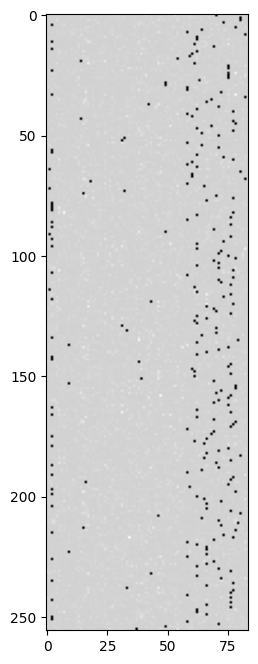

In [140]:
plt.figure(figsize=(8, 8))
plt.imshow(dlogits.cpu().detach(), cmap='gray')

## BATCHNORM FORMULA:

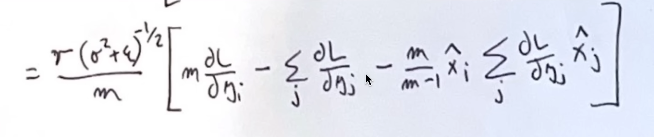

In [141]:
#backprop of batchnorm using it's mathematical formulae
preactivation_fast = bngain * (hprebn - hprebn.mean(0, keepdim = True)) / torch.sqrt(hprebn.var(0, keepdim = True, unbiased = True) + 1e-5) + bnbias
print('max diff:', (preactivation_fast - pre_activation).abs().max())

dhprebn = bngain * bnvariance_inv/n * (n * dpreactivation - dpreactivation.sum(0) - n/(n-1) * bnraw * (dpreactivation * bnraw).sum(0))
#REFER FROM 1:38:25 IN KARPATHY'S VIDEO FOR THE EXPLANATION

max diff: tensor(7.1526e-07, device='cuda:0', grad_fn=<MaxBackward1>)


In [142]:
#final manual backprop (all put together):
#cross entropy/softmax
dlogits = f.softmax(logits, 1)
dlogits[range(n) , Yb] -= 1
dlogits /= n
#2nd layer
dhidden = dlogits @ W2.T
dW2 = dhidden.T @ dlogits
db2 = dlogits.sum(0)
#tanh
dpreactivation = (1.0 - hidden**2) * dhidden
#batchnorm backprop
dbngain = (bnraw*dpreactivation).sum(0, keepdim=True)
dbnbias = dpreactivation.sum(0, keepdim=True)
dhprebn = bngain * bnvariance_inv/n * (n * dpreactivation - dpreactivation.sum(0) - n/(n-1) * bnraw * (dpreactivation * bnraw).sum(0))
#1st layer
demb_flat = dhprebn @ W1.T
dW1 = demb_flat.T @ dhprebn
db1 = dhprebn.sum(0)
#embedding
demb = demb_flat.view(emb.shape)
dC = torch.zeros_like(C)
for i in range(Xb.shape[0]):
    for j in range(Xb.shape[1]):
        ix = Xb[i, j]
        dC[ix] += demb[i, j]

grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]


In [143]:
print(dlogits[-1])
print("sum = ", dlogits[-1].sum())

tensor([ 6.9892e-06,  2.4813e-05,  6.4242e-06,  2.2912e-06,  1.5925e-04,
         2.2599e-05,  7.8970e-05,  5.0471e-06,  4.4841e-05,  1.2862e-05,
         5.1536e-05,  2.5894e-05,  7.3613e-05,  5.9472e-06,  2.4901e-04,
         2.8950e-05,  9.4572e-06,  4.1153e-05,  2.5566e-05,  3.6640e-05,
         5.0157e-05,  4.4605e-05,  1.6056e-05,  1.7267e-05,  5.2711e-06,
         5.3628e-05,  1.9909e-04,  8.2223e-05,  1.0939e-05,  2.3016e-05,
         9.1507e-05,  9.6519e-05,  4.3207e-05,  1.6306e-05,  4.2132e-05,
         1.0366e-05,  5.1703e-05, -3.8876e-03,  6.7465e-06,  9.7815e-06,
         5.6168e-06,  1.1803e-05,  1.5028e-05,  3.4918e-05,  7.3641e-05,
         5.8291e-05,  7.6538e-05,  1.9817e-04,  1.1518e-05,  3.6511e-05,
         1.8990e-05,  3.9623e-05,  6.3618e-06,  3.7727e-06,  4.3920e-04,
         1.0045e-05,  2.2889e-05,  7.2886e-05,  1.1357e-05,  2.3841e-04,
         9.0401e-05,  3.4141e-05,  1.1339e-04,  1.1694e-05,  5.3627e-05,
         2.7277e-06,  1.2569e-05,  2.0836e-05,  1.4

In [144]:
# BATCHNORM LAYER
print("dpreactivation:", dpreactivation.shape)
print("bnraw:", bnraw.shape)
print("bnraw*dpreactivation:", (bnraw*dpreactivation).shape)
print("bnbias:", bnbias.shape)
print("dbnbias:", dbnbias.shape)
print("bnvariance_inv:", bnvariance_inv.shape)

# BATCHNORM LAYER CONT.
print("bnvariance:", bnvariance.shape)
print("bndiff_sq:", bndiff_sq.shape)
print("dbndiff_sq:", dbndiff_sq.shape)

# BATCHNORM LAYER CONT.
print("bndiff:", bndiff.shape)
print("hprebn:", hprebn.shape)
print("bnmeani:", bnmeani.shape)

# LINEAR LAYER 1
print("hprebn:", hprebn.shape)
print("emb_flat:", emb_flat.shape)
print("W1:", W1.shape)
print("b1:", b1.shape)

# EMBEDDING LAYER
print("emb:", emb.shape)
print("demb:", demb.shape)

# EMBEDDING LAYER CONT.
print("Xb[0][0]:", Xb[0][0])
print()
print("demb[0][0]:", demb[0][0])

dpreactivation: torch.Size([256, 200])
bnraw: torch.Size([256, 200])
bnraw*dpreactivation: torch.Size([256, 200])
bnbias: torch.Size([1, 200])
dbnbias: torch.Size([1, 200])
bnvariance_inv: torch.Size([1, 200])
bnvariance: torch.Size([1, 200])
bndiff_sq: torch.Size([256, 200])
dbndiff_sq: torch.Size([256, 200])
bndiff: torch.Size([256, 200])
hprebn: torch.Size([256, 200])
bnmeani: torch.Size([1, 200])
hprebn: torch.Size([256, 200])
emb_flat: torch.Size([256, 30])
W1: torch.Size([30, 200])
b1: torch.Size([200])
emb: torch.Size([256, 3, 10])
demb: torch.Size([256, 3, 10])
Xb[0][0]: tensor(76, device='cuda:0')

demb[0][0]: tensor([-0.0008, -0.0001, -0.0004,  0.0009, -0.0005,  0.0007, -0.0002,  0.0009,
         0.0010, -0.0002], device='cuda:0', grad_fn=<SelectBackward0>)
